In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("All imports loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports loaded!


In [ ]:
# Load the Data
csv_path = '/content/drive/MyDrive/Industrial-Predictive-Maintenance/predictive_maintenance.csv'
df = pd.read_csv(csv_path)

print("Data Overview")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Data Overview
Total rows: 10000
Total columns: 12
Columns: ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Missing Values:
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

Data Types:
Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object


In [ ]:
# Exploratory Data Analysis (EDA)

print("Target Distributions")
print(df['Machine failure'].value_counts())
print(f"Failure rate: {df['Machine failure'].mean()*100:.2f}%")

# failure types breakdown
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("\nFailure Type Distribution:")
for ft in failure_types:
  count = df[ft].sum()
  print(f"{ft}: {count} failures ({count/len(df)*100:.2f}%)")

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# To check columns names in Data
print("\nColumn Names:")
print(df.columns.tolist())


Target Distributions
Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure rate: 3.39%

Failure Type Distribution:
TWF: 46 failures (0.46%)
HDF: 115 failures (1.15%)
PWF: 95 failures (0.95%)
OSF: 98 failures (0.98%)
RNF: 19 failures (0.19%)

Statistical Summary:
       Air temperature  Process temperature  Rotational speed        Torque  \
count     10000.000000         10000.000000      10000.000000  10000.000000   
mean        300.004930           310.005560       1538.776100     39.986910   
std           2.000259             1.483734        179.284096      9.968934   
min         295.300000           305.700000       1168.000000      3.800000   
25%         298.300000           308.800000       1423.000000     33.200000   
50%         300.100000           310.100000       1503.000000     40.100000   
75%         301.500000           311.100000       1612.000000     46.800000   
max         304.500000           313.800000       2886.000000     76.600000   

         

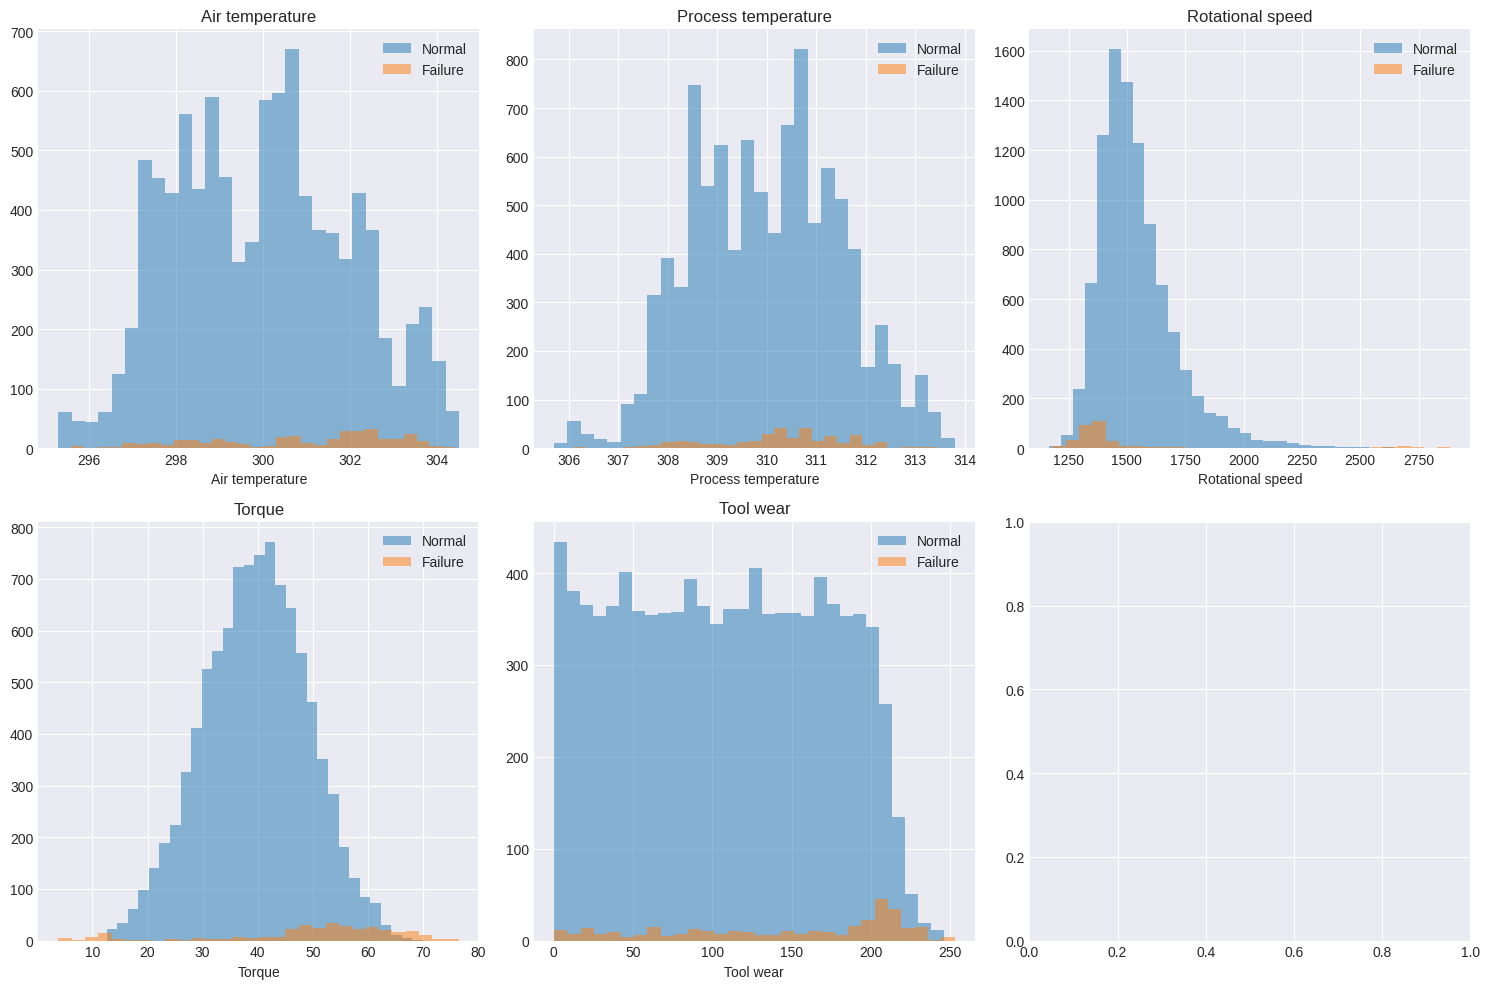

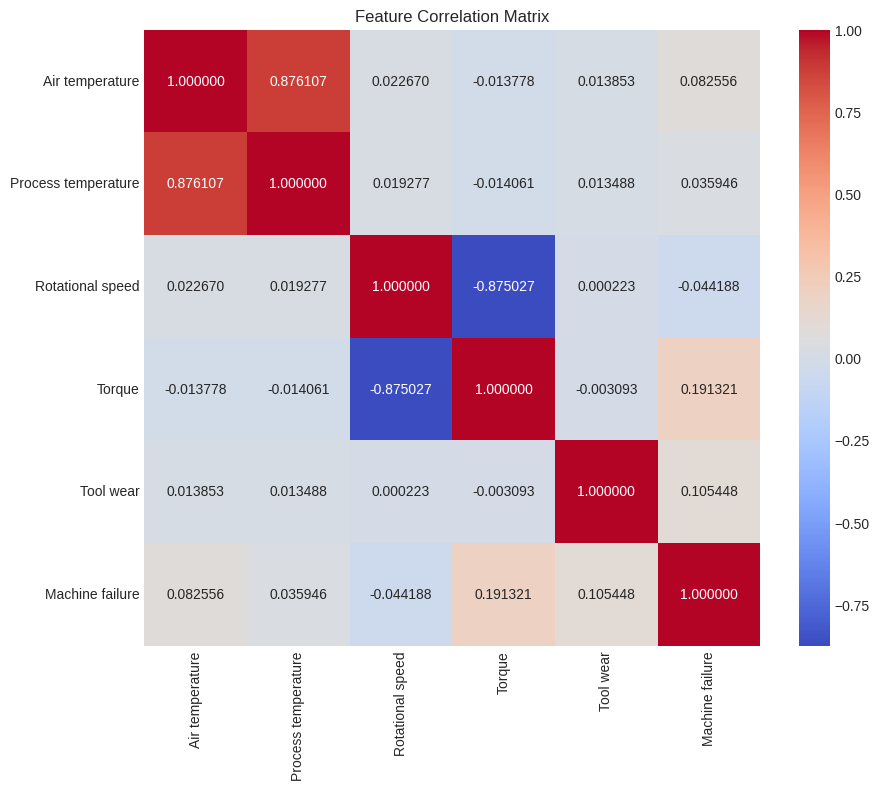

In [ ]:
# (EDA) - Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Use actual column names from data
features = ['Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear']

for i, (ax, feature) in enumerate(zip(axes.flatten(), features)):
  if feature in df.columns:
    for target in [0, 1]:
      subset = df[df['Machine failure'] == target][feature]
      label = 'Normal' if target == 0 else 'Failure'
      ax.hist(subset, alpha=0.5, label=label, bins=30)
    ax.set_title(f'{feature}')
    ax.legend()
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_cols = ['Air temperature', 'Process temperature',
                'Rotational speed', 'Torque', 'Tool wear',
                'Machine failure']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='2f', square=True)
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# Feature Engineering
df_engineered = df.copy()

# 1. Temperature difference (Process - Air)
df_engineered['temp_diff'] = df_engineered['Process temperature'] - df_engineered['Air temperature']

# 2. Power (Torque * Rotational speed)
df_engineered['power'] = df_engineered['Torque'] * df_engineered['Rotational speed']

# 3. Tool wear ratio (wear relative to max)
df_engineered['tool_wear-ratio'] = df_engineered['Tool wear'] / 255

# 4. Efficiency (rotational speed / Process temperature)
df_engineered['efficiency'] = df_engineered['Rotational speed'] / df_engineered['Process temperature']

# 5. Thermal stress (Process temperature - Air temperature) / Air temperature
df_engineered['thermal_stress'] = (df_engineered['Process temperature'] - df_engineered['Air temperature']) / df_engineered['Air temperature']

# 6. Torque to speed ratio (torque / Rotational speed)
df_engineered['torque_speed_ratio'] = df_engineered['Torque'] / df_engineered['Rotational speed']

# 7. Temperature ratio
df_engineered['temp_ratio'] = df_engineered['Process temperature'] / df_engineered['Air temperature']

print(f"Added {len(df_engineered.columns) - len(df.columns)} new features")
print(f"New features set size: {df_engineered.shape[1]} columns")
print("\nNew features added:")
new_features = ['temp_diff', 'power', 'tool_wear_ratio', 'efficiency',
                'thermal_stress', 'torque_speed_ratio']
for feat in new_features:
  print(f" - {feat}")

Added 7 new features
New features set size: 19 columns

New features added:
 - temp_diff
 - power
 - tool_wear_ratio
 - efficiency
 - thermal_stress
 - torque_speed_ratio


In [ ]:
# Encode Categorial Variables
df_encoded = pd.get_dummies(df_engineered, columns=['Type'], prefix='Type', drop_first=True)

print(f"After Encoding: {df_encoded.shape[1]} columns")
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())


After Encoding: 20 columns

Columns after encoding:
['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_diff', 'power', 'tool_wear-ratio', 'efficiency', 'thermal_stress', 'torque_speed_ratio', 'temp_ratio', 'Type_L', 'Type_M']


In [ ]:
# Split data
print("Data Splitting")

# Define features and target
exclude_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
x = df_encoded[feature_cols]
y = df_encoded['Machine failure']

# First split: train+val (80%) and test (20%)
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: tain (75% of original) and val (25% of original)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"train set: {x_train.shape[0]} samples ({y_train.mean()*100:.2f}% failure)")
print(f"Validation set: {x_val.shape[0]} samples ({y_val.mean()*100:.2f}% failure)")
print(f"Test set: {x_test.shape[0]} samples ({y_test.mean()*100:.2f}% failure)")

Data Splitting
train set: 6000 samples (3.38% failure)
Validation set: 2000 samples (3.40% failure)
Test set: 2000 samples (3.40% failure)


In [ ]:
# Preprocessing & Scaling

print("Preprocessing")

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.3)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

print(f"Before SMOTE: {len(y_train)} samples, {y_train.mean()*100:.2f}% failure")
print(f"After SMOTE: {len(y_train_resampled)} samples, {y_train_resampled.mean()*100:.2f}% failure")
print(f"No NaNs in scaled data: {np.isnan(x_train_scaled).sum()}")

Preprocessing
Before SMOTE: 6000 samples, 3.38% failure
After SMOTE: 7536 samples, 23.08% failure
No NaNs in scaled data: 0


Model Training and Evaluation

Training Logistic Regression
Accuracy: 0.9385
Precision: 0.3226
Recall: 0.7353
F1-Score: 0.4484
ROC-AUC: 0.9287

Training Decision Tree
Accuracy: 0.9700
Precision: 0.5426
Recall: 0.7500
F1-Score: 0.6296
ROC-AUC: 0.8026

Training Random Forest
Accuracy: 0.9820
Precision: 0.7000
Recall: 0.8235
F1-Score: 0.7568
ROC-AUC: 0.9697

Training Gradient Boosting
Accuracy: 0.9830
Precision: 0.7073
Recall: 0.8529
F1-Score: 0.7733
ROC-AUC: 0.9808

Training XGBoost
Accuracy: 0.9850
Precision: 0.7639
Recall: 0.8088
F1-Score: 0.7857
ROC-AUC: 0.9763

Training SVM
Accuracy: 0.9685
Precision: 0.5234
Recall: 0.8235
F1-Score: 0.6400
ROC-AUC: 0.9714
Model Comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9385,0.322581,0.735294,0.448430,0.928724
Decision Tree,0.9700,0.542553,0.750000,0.629630,0.802582
Random Forest,0.9820,0.700000,0.823529,0.756757,0.969656
Gradient Boosting,0.9830,0.707317,0.852941,0.773333,0.980769
XGBoost,0.9850,0.763889,0.808824,0.785714,0.976320
SVM,0.9685,0.523364,0.823529,0.640000,0.971380


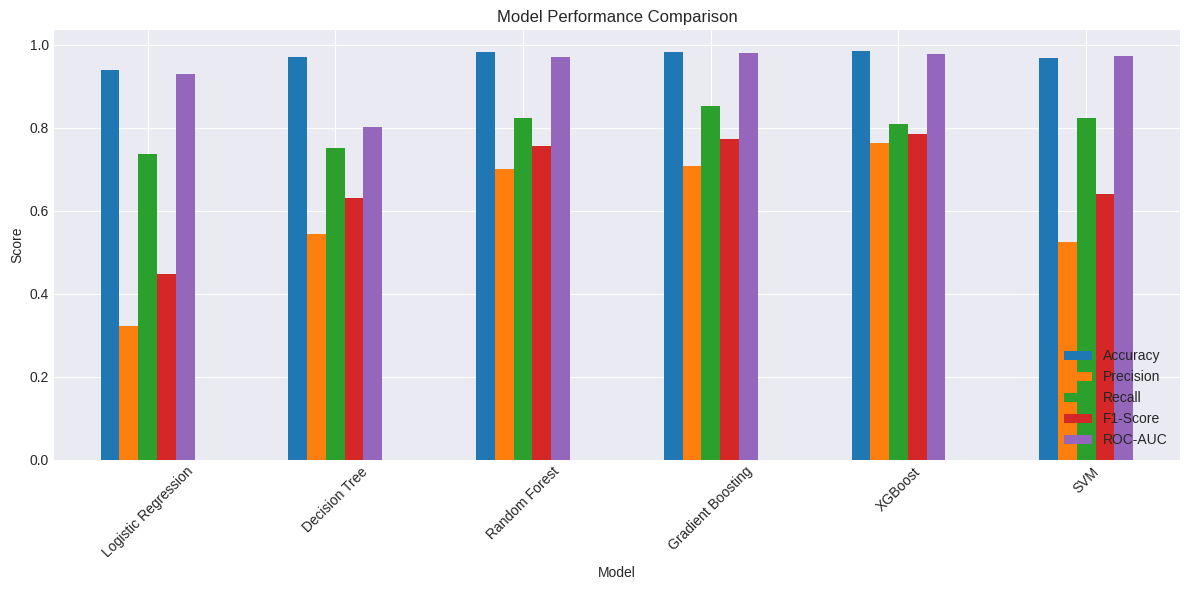

Best Model: XGBoost with F1-Score: 0.7857


In [ ]:
# Train and Evaluate Models

print("Model Training and Evaluation")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

# Train and evaluate each model
results = {}
best_model = None
best_f1 = 0
best_model_name = ""

for name, model in models.items():
  print(f"\nTraining {name}")

  # Train
  model.fit(x_train_resampled, y_train_resampled)

  # Predict
  y_pred = model.predict(x_test_scaled)
  y_pred_proba = model.predict_proba(x_test_scaled)[:, 1]

  # Calculate metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred_proba)

  results[name] = {
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1-Score': f1,
      'ROC-AUC': auc
  }

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-Score: {f1:.4f}")
  print(f"ROC-AUC: {auc:.4f}")

  # Track best model
  if f1 > best_f1:
    best_f1 = f1
    best_model = model
    best_model_name = name

print("Model Comparison")
results_df = pd.DataFrame(results).T
display(results_df)

# Plot comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Best Model: {best_model_name} with F1-Score: {best_f1:.4f}")

In [ ]:
# Best Model - Final training
print(f"Best Model: {best_model_name}")

# Retrain the best model with all training data including validation
x_train_full = np.vstack([x_train_scaled, x_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

# Apply SMOTE on full training data
x_train_full_resampled, y_train_full_resampled = smote.fit_resample(x_train_full, y_train_full)

# # Train final model
best_model.fit(x_train_full_resampled, y_train_full_resampled)

# Predict on test set
y_pred = best_model.predict(x_test_scaled)
y_pred_proba = best_model.predict_proba(x_test_scaled)[:, 1]

# Final Metrics
print(f"\nFinal Performance on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

Best Model: XGBoost

Final Performance on Test Set:
Accuracy: 0.9805
Precision: 0.6790
Recall:    0.8088
F1-Score:  0.7383
ROC-AUC:   0.9817


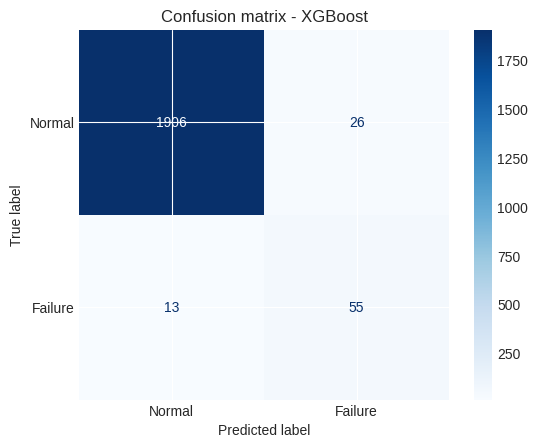


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.68      0.81      0.74        68

    accuracy                           0.98      2000
   macro avg       0.84      0.90      0.86      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix Breakdown:
True Negatives (Normal correctly predicted): 1906
False Positives (Normal predicted as Failure): 26
False Negatives (Failure predicted as Normal): 13
True Positives (Failure correctly predicted): 55


In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Failure'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion matrix - {best_model_name}')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

# Claculate and print specific metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Normal correctly predicted): {tn}")
print(f"False Positives (Normal predicted as Failure): {fp}")
print(f"False Negatives (Failure predicted as Normal): {fn}")
print(f"True Positives (Failure correctly predicted): {tp}")

ROC Curve


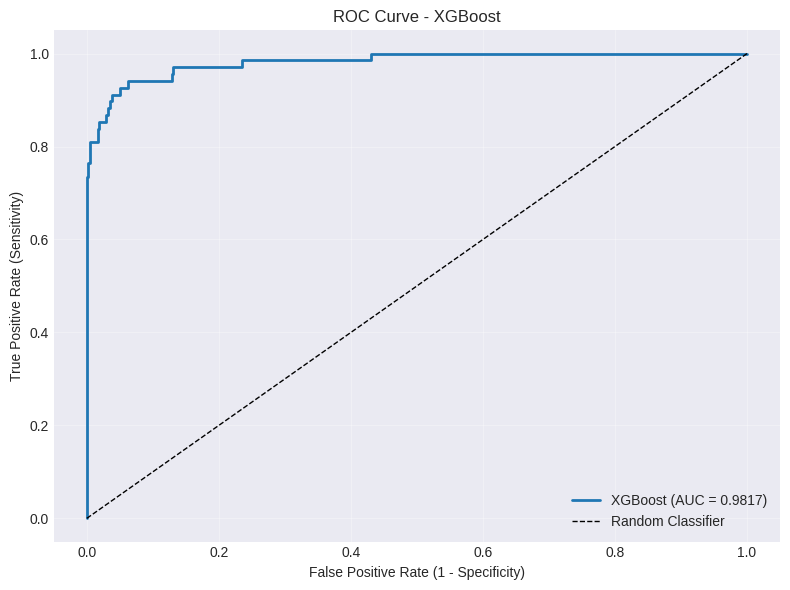

ROC-AUC Score: 0.9817
Interpretation: The model has 98.2% chance of distinguishing between failure and normal cases


In [ ]:
# ROC curve
print("ROC Curve")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Interpretation: The model has {auc_score*100:.1f}% chance of distinguishing between failure and normal cases")

Feature Importance Ananlysis

Top 10 features:


,Feature,Importance
2,Rotational speed,0.257015
10,torque_speed_ratio,0.191670
4,Tool wear,0.123097
6,power,0.121697
3,Torque,0.078311
5,temp_diff,0.065723
8,efficiency,0.061205
12,Type_L,0.032168
0,Air temperature,0.019410
13,Type_M,0.019037


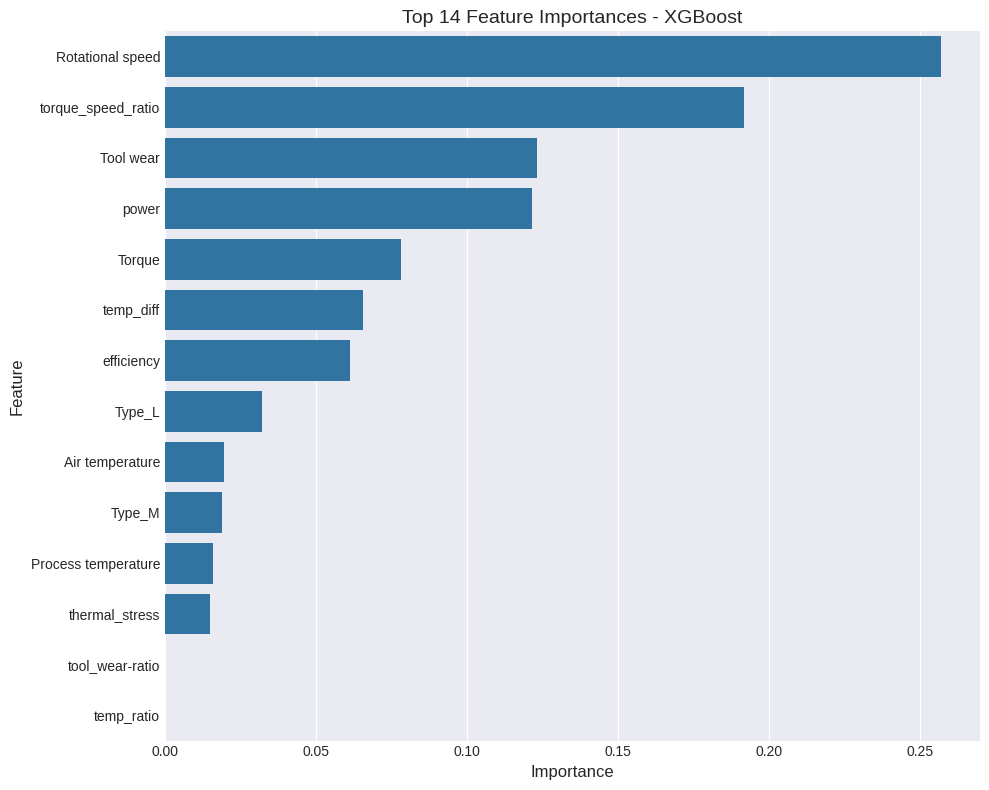


Top 5 features explain {importances.head(5)['Importance],sum()*100:.1f}% of importance

Top 10 features explain {importances.head(10)['Importance'].sum()*100:.1f}% of importance


In [ ]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
  print("Feature Importance Ananlysis")

  importances = pd.DataFrame({
      'Feature': x_train.columns,
      'Importance': best_model.feature_importances_
  }).sort_values('Importance', ascending=False)

  print("\nTop 10 features:")
  display(importances.head(10))

# Plot top features
  plt.figure(figsize=(10, 8))
  top_n = min(15, len(importances))
  sns.barplot(data=importances.head(top_n), y='Feature', x='Importance')
  plt.title(f'Top {top_n} Feature Importances - {best_model_name}', fontsize=14)
  plt.xlabel('Importance', fontsize=12)
  plt.ylabel('Feature', fontsize=12)
  plt.tight_layout()
  plt.show()

# Cumulative importance
  importances['Cumulative'] = importances['Importance'].cumsum()
  print("\nTop 5 features explain {importances.head(5)['Importance],sum()*100:.1f}% of importance")
  print("\nTop 10 features explain {importances.head(10)['Importance'].sum()*100:.1f}% of importance")
else:
    print(f"{best_model_name} doesn't have feature_importances_ attribute")

In [ ]:
# Saving model
# create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model, scaler and feature names
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(x_train.columns.tolist(), 'models/feature_names.pkl')
joblib.dump(smote, 'models/smote.pkl')

print("Model saved as 'models/best_model.pkl'")
print("Scaler saved as 'models/scaler.pkl'")
print("Feature names saved as 'models/feature_names.pkl'")
print("SMOTE object saved as 'models/smote.pkl'")

# Save results summary
results_df.to_csv('models/model_results.csv')
print("Results saved as 'models/model_results.csv'")

Model saved as 'models/best_model.pkl'
Scaler saved as 'models/scaler.pkl'
Feature names saved as 'models/feature_names.pkl'
SMOTE object saved as 'models/smote.pkl'
Results saved as 'models/model_results.csv'
